In [9]:
from data_loader import X_train, y_train
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFECV
from sklearn.metrics import make_scorer, recall_score
from sklearn.svm import SVC

import matplotlib.pyplot as plt

In [3]:
data = X_train
if isinstance(data, np.ndarray):
    n_features = data.shape[1]
    feature_names = [f"feature_{i}" for i in range(n_features)]
    df = pd.DataFrame(data, columns=feature_names)

In [8]:
df

,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,...,feature_490,feature_491,feature_492,feature_493,feature_494,feature_495,feature_496,feature_497,feature_498,feature_499
0,10.040733,8.257999,18.613865,14.577990,12.998063,9.495847,10.738162,11.182029,8.885421,8.169846,...,9.883276,14.548635,6.378488,14.981905,20.667101,12.347273,7.001375,23.799200,17.619227,11.280553
1,11.304127,12.853286,20.324398,13.797133,16.143076,5.762128,12.995544,11.962030,12.080032,15.192965,...,3.718966,16.909202,13.921243,9.525220,10.046930,11.299053,7.757694,6.604152,7.908963,4.627572
2,4.312497,4.439501,12.052981,8.644045,5.317511,1.941863,8.386999,3.807933,5.129873,7.100559,...,8.640348,2.229632,12.068508,7.060449,10.904716,15.627423,10.510861,13.421498,11.716831,8.308786
3,12.826421,10.918191,27.491819,18.449703,16.265946,12.102726,20.690248,13.456360,16.483470,14.713693,...,3.413879,5.241452,7.865612,9.288564,10.978212,12.488029,13.715541,8.166234,3.537022,1.469003
4,14.807351,10.321640,23.377204,17.239950,16.685754,12.450999,19.747679,14.347073,13.263354,14.639188,...,8.863018,6.162232,11.375893,12.583986,4.014357,10.436561,5.747138,13.868681,5.877561,4.944254
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3995,11.263572,8.892599,25.510205,17.568675,14.393706,12.020761,20.331658,12.231724,14.847722,12.866228,...,4.426436,9.499404,10.140017,20.506732,21.885045,4.136666,16.870620,17.205493,7.760577,3.248879
3996,7.028737,7.004667,16.131225,8.798373,11.081224,4.108798,8.997221,8.311404,4.276434,9.491842,...,6.512561,5.218618,7.149461,5.580810,12.893151,5.269749,11.099959,9.253920,13.769209,16.102519
3997,20.711825,18.289805,37.668298,25.043170,25.202040,14.435063,25.449696,19.546859,21.654535,23.252546,...,11.855394,10.666771,2.653979,17.211993,10.956435,8.220232,15.221059,10.344640,13.463985,11.218050
3998,7.282849,5.182932,11.214880,9.468093,7.278282,5.936123,9.092305,6.986023,6.644297,8.423423,...,14.163693,4.945396,10.188483,7.059473,6.259487,7.074831,13.202192,9.006438,12.636995,6.065497


In [7]:
print(f"Number of ones: {y_train.sum()}")
print(f"Number of zeros: {len(y_train) - y_train.sum()}")
print(f"Percentage of ones: {y_train.mean() * 100:.2f}%")

Number of ones: 1955
Number of zeros: 2045
Percentage of ones: 48.88%


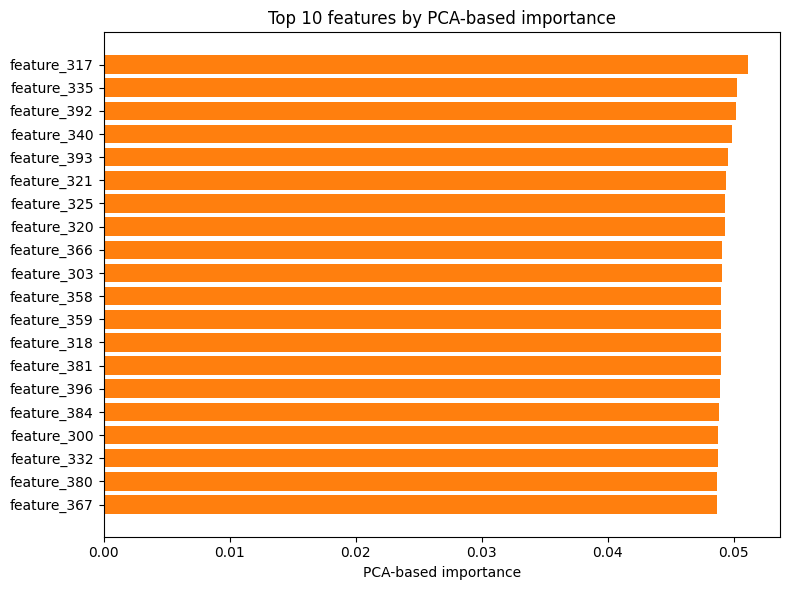

In [ ]:
scaler = MinMaxScaler(feature_range=(0, 1))
X_scaled = scaler.fit_transform(df)
pca = PCA()
pca.fit(X_scaled)
components = pca.components_
explained = pca.explained_variance_ratio_
importances = np.sum(np.abs(components) * explained[:, np.newaxis], axis=0)
feat_imp = pd.DataFrame({"feature": feature_names, "importance": importances})
top10 = feat_imp.sort_values("importance", ascending=False).head(20)
fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(top10["feature"][::-1], top10["importance"][::-1], color="tab:orange")
ax.set_xlabel("PCA-based importance")
ax.set_title("Top 20 features by PCA-based importance")
plt.tight_layout()
plt.show()

In [ ]:
k = 20
base_estimator = RandomForestClassifier(n_estimators=50, random_state=42)
recall_scorer = make_scorer(recall_score, pos_label=1)
rfecv = RFECV(
    estimator=base_estimator,
    min_features_to_select=k,
    step=1,
    cv=3,
    scoring=recall_scorer,
    n_jobs=-1,
)
rfecv.fit(X_scaled, y_train)
support_mask = rfecv.support_
ranking = rfecv.ranking_
n_selected = rfecv.n_features_



Optimal number of features (RFECV): 102
Selected feature indices: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 18, 22, 28, 30, 43, 49, 51, 60, 63, 74, 75, 78, 81, 83, 88, 102, 113, 115, 118, 121, 125, 139, 140, 144, 149, 151, 169, 170, 181, 194, 201, 202, 213, 215, 216, 218, 226, 227, 228, 229, 238, 242, 245, 251, 252, 254, 255, 259, 266, 271, 283, 286, 288, 298, 301, 306, 314, 323, 332, 333, 334, 344, 351, 352, 362, 364, 367, 376, 382, 385, 395, 405, 412, 414, 422, 425, 431, 436, 445, 451, 452, 460, 461, 462, 463, 472, 473, 478, 479, 485, 488, 491]
Selected feature names: ['feature_0', 'feature_1', 'feature_2', 'feature_3', 'feature_4', 'feature_5', 'feature_6', 'feature_7', 'feature_8', 'feature_9', 'feature_18', 'feature_22', 'feature_28', 'feature_30', 'feature_43', 'feature_49', 'feature_51', 'feature_60', 'feature_63', 'feature_74', 'feature_75', 'feature_78', 'feature_81', 'feature_83', 'feature_88', 'feature_102', 'feature_113', 'feature_115', 'feature_118', 'feature_121', 'feature_125', 'f

C:\Users\SPCX\AppData\Local\Temp\ipykernel_31752\1466957792.py:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


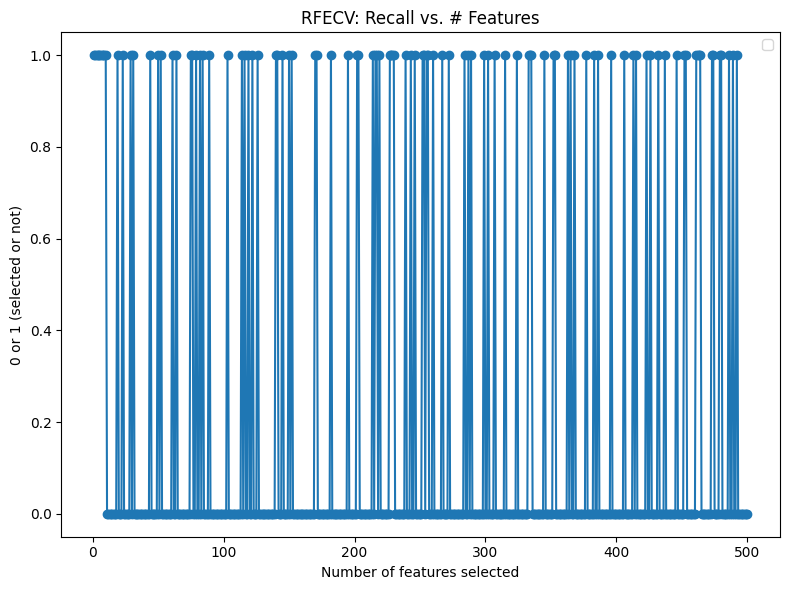

In [25]:
grid_score = ranking == 1
selected_indices = np.where(support_mask)[0]
selected_feature_names = [feature_names[i] for i in selected_indices]
print(f"\nOptimal number of features (RFECV): {n_selected}")
print("Selected feature indices:", selected_indices.tolist())
print("Selected feature names:", selected_feature_names)
fig, ax = plt.subplots(figsize=(8, 6))
num_features_list = np.arange(1, len(grid_score) + 1)
ax.plot(num_features_list, grid_score, marker="o", linestyle="-")
ax.set_xlabel("Number of features selected")
ax.set_ylabel("0 or 1 (selected or not)")
ax.set_title("RFECV: Recall vs. # Features")
ax.legend()
plt.tight_layout()
plt.show()

In [26]:
def business_scorer_rfecv(estimator, X_val, y_val):
    proba = estimator.predict_proba(X_val)[:, 1]
    n_val = len(proba)
    top_k = max(1, int(np.floor(0.2 * n_val)))
    top_indices = np.argsort(proba)[::-1][:top_k]
    tp = np.sum(y_val[top_indices] == 1)
    k_features = X_val.shape[1]
    return 10 * int(tp) - 200 * k_features

In [27]:
k = 5
base_estimator = RandomForestClassifier(n_estimators=50, random_state=0)
rfecv = RFECV(
    estimator=base_estimator,
    min_features_to_select=k,
    step=0.02,
    cv=3,
    scoring=business_scorer_rfecv,
    n_jobs=-1,
)
rfecv.fit(X_scaled, y_train)
support_mask = rfecv.support_
ranking = rfecv.ranking_
n_selected = rfecv.n_features_
selected_indices = np.where(support_mask)[0].tolist()
print(f"Optimal number of features (RFECV): {n_selected}")
print(f"Selected feature indices: {selected_indices}")

Optimal number of features (RFECV): 5
Selected feature indices: [2, 3, 4, 6, 8]


In [29]:
rfecv.cv_results_

{'mean_test_score': array([ 9.63333333e+02, -2.33333333e+01, -2.05666667e+03, -4.05000000e+03,
        -6.01666667e+03, -8.04666667e+03, -1.00700000e+04, -1.20233333e+04,
        -1.40400000e+04, -1.60133333e+04, -1.80233333e+04, -2.00100000e+04,
        -2.20233333e+04, -2.40700000e+04, -2.60600000e+04, -2.80833333e+04,
        -3.01033333e+04, -3.20466667e+04, -3.40300000e+04, -3.60100000e+04,
        -3.80466667e+04, -4.00566667e+04, -4.20866667e+04, -4.40600000e+04,
        -4.60800000e+04, -4.80733333e+04, -5.00666667e+04, -5.20766667e+04,
        -5.40500000e+04, -5.60066667e+04, -5.80800000e+04, -6.00600000e+04,
        -6.20300000e+04, -6.40133333e+04, -6.60966667e+04, -6.80400000e+04,
        -7.00500000e+04, -7.20766667e+04, -7.40333333e+04, -7.60566667e+04,
        -7.80566667e+04, -8.00733333e+04, -8.20066667e+04, -8.40333333e+04,
        -8.60700000e+04, -8.80933333e+04, -9.00500000e+04, -9.20633333e+04,
        -9.40166667e+04, -9.60166667e+04, -9.80700000e+04]),
 'std_te

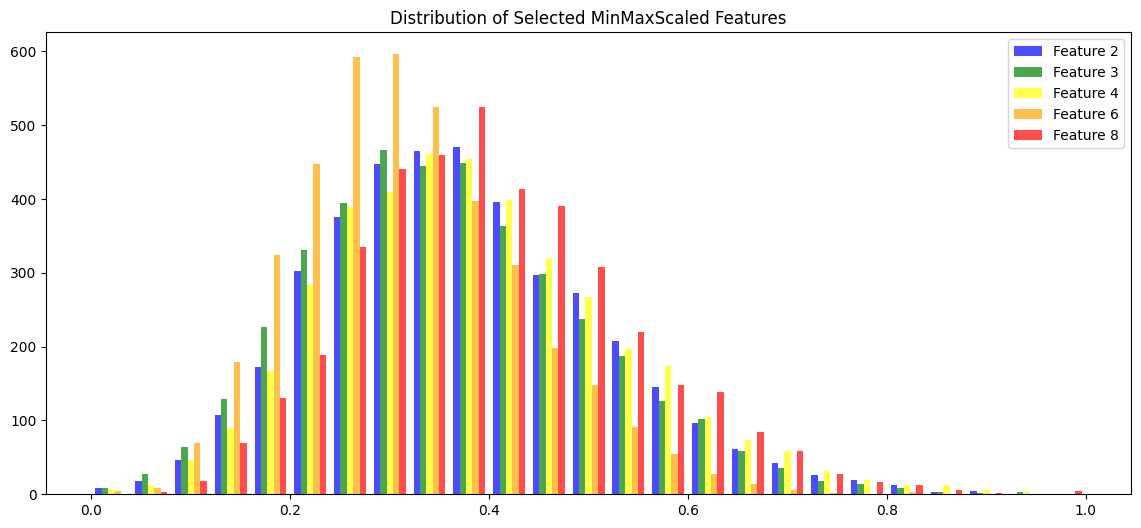

Feature 2 mean is 0.38, std is 0.14
Feature 3 mean is 0.36, std is 0.14
Feature 4 mean is 0.39, std is 0.15
Feature 6 mean is 0.32, std is 0.11
Feature 8 mean is 0.40, std is 0.14


In [40]:
plt.figure(figsize=(14, 6))
plt.hist(
    X_scaled[:, [2, 3, 4, 6, 8]],
    bins=25,
    color=["blue", "green", "yellow", "orange", "red"],
    alpha=0.7,
)
plt.title("Distribution of Selected MinMaxScaled Features")
plt.legend(["Feature 2", "Feature 3", "Feature 4", "Feature 6", "Feature 8"])
plt.show()
print(
    f"Feature 2 mean is {X_scaled[:, 2].mean():.2f}, std is {X_scaled[:, 2].std():.2f}"
)
print(
    f"Feature 3 mean is {X_scaled[:, 3].mean():.2f}, std is {X_scaled[:, 3].std():.2f}"
)
print(
    f"Feature 4 mean is {X_scaled[:, 4].mean():.2f}, std is {X_scaled[:, 4].std():.2f}"
)
print(
    f"Feature 6 mean is {X_scaled[:, 6].mean():.2f}, std is {X_scaled[:, 6].std():.2f}"
)
print(
    f"Feature 8 mean is {X_scaled[:, 8].mean():.2f}, std is {X_scaled[:, 8].std():.2f}"
)

In [42]:
from data_loader import X_test, y_test

In [53]:
rf = RandomForestClassifier(n_estimators=50, max_depth=1, random_state=42, n_jobs=-1)
rf.fit(X_scaled[:, 2].reshape(-1, 1), y_train)
X_test_scaled = scaler.transform(X_test)
print(
    f"Random Forest accuracy: {rf.score(X_test_scaled[:, 2].reshape(-1, 1), y_test):.4f}"
)
print(
    f"Business score: {business_scorer_rfecv(rf, X_test_scaled[:, 2].reshape(-1, 1), y_test)}"
)

Random Forest accuracy: 0.6910
Business score: 1250


c:\Users\SPCX\Desktop\github-repositories\aml-project2\.venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


In [11]:
x_train = pd.read_csv("data/x_train.txt", sep=" ", header=None)
x_test = pd.read_csv("data/x_test.txt", sep=" ", header=None)

(array([  5.,   6.,   8.,  19.,  26.,  44.,  65., 101., 136., 163., 238.,
        220., 271., 260., 307., 272., 303., 323., 298., 263., 234., 217.,
        211., 167., 161., 131., 134.,  94.,  65.,  56.,  44.,  25.,  33.,
         23.,  23.,  14.,  11.,   2.,   3.,   8.,   0.,   3.,   4.,   3.,
          2.,   0.,   1.,   1.,   0.,   2.]),
 array([10.17942406, 11.17538551, 12.17134696, 13.16730842, 14.16326987,
        15.15923132, 16.15519277, 17.15115423, 18.14711568, 19.14307713,
        20.13903859, 21.13500004, 22.13096149, 23.12692294, 24.1228844 ,
        25.11884585, 26.1148073 , 27.11076876, 28.10673021, 29.10269166,
        30.09865311, 31.09461457, 32.09057602, 33.08653747, 34.08249892,
        35.07846038, 36.07442183, 37.07038328, 38.06634474, 39.06230619,
        40.05826764, 41.05422909, 42.05019055, 43.046152  , 44.04211345,
        45.03807491, 46.03403636, 47.02999781, 48.02595926, 49.02192072,
        50.01788217, 51.01384362, 52.00980508, 53.00576653, 54.00172798,
 

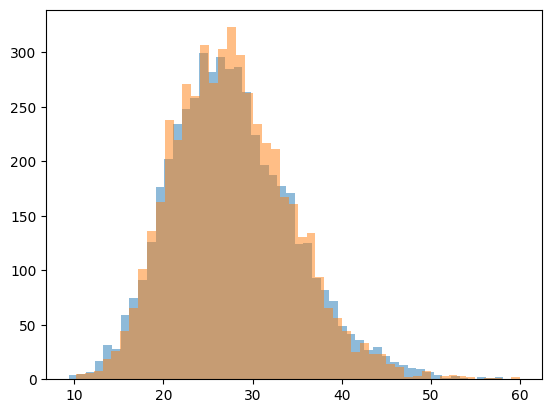

In [12]:
plt.hist(x_train[2], bins=50, alpha=0.5, label="Train Feature 2")
plt.hist(x_test[2], bins=50, alpha=0.5, label="Test Feature 2")

In [13]:
x_train[2].describe(), x_test[2].describe()

(count    5000.000000
 mean       27.750084
 std         6.946855
 min         9.361016
 25%        22.814920
 50%        27.110561
 75%        32.077128
 max        58.144148
 Name: 2, dtype: float64,
 count    5000.000000
 mean       27.736016
 std         6.634691
 min        10.179424
 25%        22.930884
 50%        27.279667
 75%        31.940146
 max        59.977497
 Name: 2, dtype: float64)